[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using device: cuda
Epoch 1: Train=0.6812, Val=0.6770, Acc=0.5872
Epoch 2: Train=0.6599, Val=0.6459, Acc=0.5888
Epoch 3: Train=0.6111, Val=0.5845, Acc=0.7020
Epoch 4: Train=0.5372, Val=0.5098, Acc=0.8164
Epoch 5: Train=0.4562, Val=0.4375, Acc=0.8632
Epoch 6: Train=0.3819, Val=0.3776, Acc=0.8808
Epoch 7: Train=0.3207, Val=0.3325, Acc=0.8916
Epoch 8: Train=0.2728, Val=0.3002, Acc=0.8984
Epoch 9: Train=0.2359, Val=0.2779, Acc=0.8992
Epoch 10: Train=0.2070, Val=0.2624, Acc=0.9008
Epoch 11: Train=0.1837, Val=0.2523, Acc=0.9032
Epoch 12: Train=0.1645, Val=0.2450, Acc=0.9040
Epoch 13: Train=0.1481, Val=0.2406, Acc=0.9064
Epoch 14: Train=0.1338, Val=0.2379, Acc=0.9056
Epoch 15: Train=0.1212, Val=0.2368, Acc=0.9060
Epoch 16: Train=0.1098, Val=0.2369, Acc=0.9052
Epoch 17: Train=0.0995, Val=0.2379, Acc=0.9052
Early stopping triggered
Nr of features: 
30000
Epoch 1: Train=0.6661, Val=0.6551, Acc=0.5872
Epoch 2: Train=0.6097, Val=0.5390, Acc=0.7316
Epoch 3: Train=0.4968, Val=0.4701, Acc=0.7644
Epoch

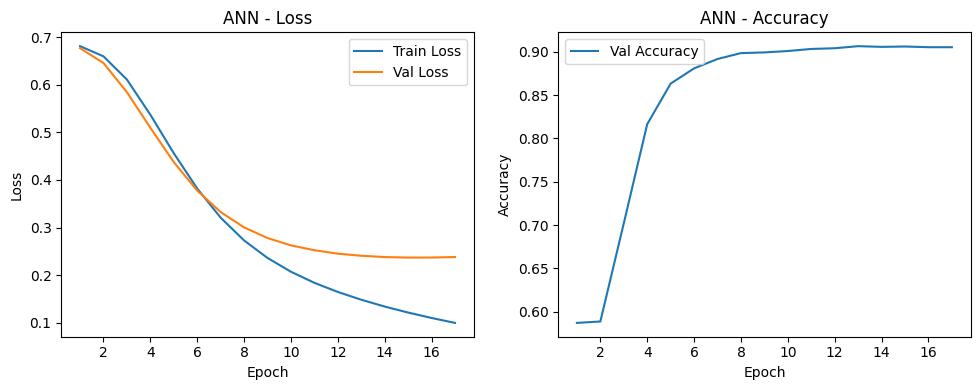

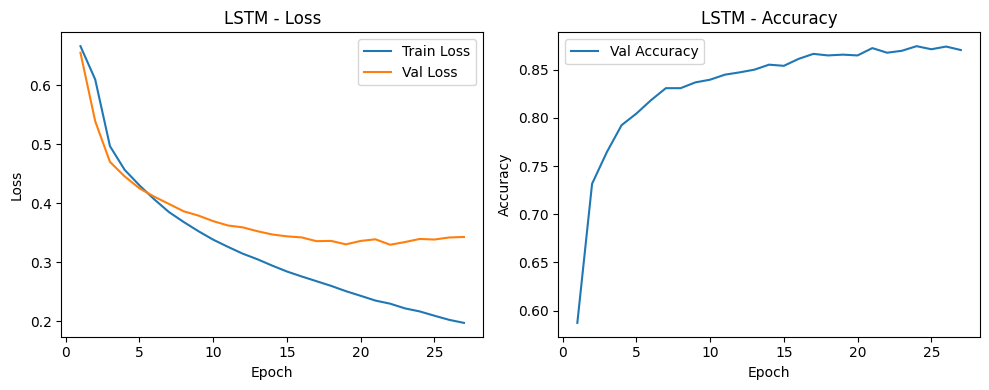

In [1]:
import torch
import nltk
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import copy

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk import word_tokenize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from collections import Counter
from torch.nn.utils.rnn import pack_padded_sequence

from comet_ml import Experiment  # optional

# -----------------------------
# NLTK SETUP
# -----------------------------
nltk.download('punkt')
nltk.download('stopwords')

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# PREPROCESSING
# -----------------------------
def preprocess_pandas(data, columns):
    df_ = pd.DataFrame(columns=columns)
    stop_words = set(stopwords.words('english'))

    data['Sentence'] = data['Sentence'].str.lower()
    data['Sentence'] = data['Sentence'].replace('[a-zA-Z0-9-_.]+@[a-zA-Z0-9-_.]+', '', regex=True)
    data['Sentence'] = data['Sentence'].replace('((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', regex=True)
    data['Sentence'] = data['Sentence'].str.replace('[^\w\s]', '', regex=True)
    data['Sentence'] = data['Sentence'].replace('\d', '', regex=True)

    for index, row in data.iterrows():
        tokens = word_tokenize(row['Sentence'])
        filtered = tokens #[w for w in tokens if w not in stop_words]

        df_.loc[len(df_)] = {
            "index": row['index'],
            "Class": row['Class'],
            "Sentence": " ".join(filtered)
        }
    return df_

# -----------------------------
# LOAD DATA FUNCTION
# -----------------------------
def load_and_prepare_data(file_path, test_size=0.10, val_size=0.10, random_state=0):
    data = pd.read_csv(file_path, delimiter='\t', header=None)
    data.columns = ['Sentence', 'Class']
    data['index'] = data.index

    data = preprocess_pandas(data, ['index', 'Class', 'Sentence'])

    train_val_text, test_text, train_val_labels, test_labels = train_test_split(
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    val_ratio = val_size / (1 - test_size)
    train_text, val_text, train_labels, val_labels = train_test_split(
        train_val_text,
        train_val_labels,
        test_size=val_ratio,
        random_state=random_state,
        shuffle=True
    )

    return train_text, val_text, test_text, train_labels, val_labels, test_labels


# -----------------------------
# SIMPLE ANN
# -----------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
        
            nn.Linear(256, 128),
            nn.ReLU(),
        
            nn.Linear(128, 2)
        )
                
#        self.net = nn.Sequential(
#            nn.Linear(input_dim, 512),
#            nn.ReLU(),

#            nn.Linear(512, 256),
#            nn.ReLU(),

#            nn.Linear(256, 128),
#            nn.ReLU(),

#            nn.Linear(128, 2)
#        )

    def forward(self, x):
        return self.net(x)


# -----------------------------
# LSTM
# -----------------------------
class LSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_size=256, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers=2,
            dropout = 0.3,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 2)

    def forward(self, x, lengths):
        x_input = x  # save original token indices
        x = self.embedding(x)

        packed = pack_padded_sequence(
            x, lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.lstm(packed)

        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=x_input.size(1)
        )

        #maxpooling + masking padding
        mask = (x_input != 0).unsqueeze(-1)  # shape: (batch, seq, 1)
        output = output.masked_fill(mask == 0, -1e9)
        pooled, _ = torch.max(output, dim=1)
        
        pooled = self.dropout(pooled)
        
        return self.fc(pooled)


# -----------------------------
# TRAINING LOOP (UNIVERSAL)
# -----------------------------
def train_model(
    model, train_loader, val_loader,
    criterion, optimizer, device, epochs,
    patience=3,
    min_epochs=0
):
    
    model = model.to(device)

    train_losses, val_losses, val_accs = [], [], []
    best_model = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            optimizer.zero_grad()

            if len(batch) == 3:
                X, y, lengths = batch
                lengths = lengths.to(device)
                outputs = model(X.to(device), lengths)
            else:
                X, y = batch
                outputs = model(X.to(device))

            y = y.long().to(device)

            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # validation
        model.eval()
        val_loss = 0
        preds_all, labels_all = [], []

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    X, y, lengths = batch
                    lengths = lengths.to(device)
                    outputs = model(X.to(device), lengths)
                else:
                    X, y = batch
                    outputs = model(X.to(device))

                y = y.long().to(device)

                loss = criterion(outputs, y)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(y.cpu().numpy())

        val_losses.append(val_loss / len(val_loader))
        acc = accuracy_score(labels_all, preds_all)
        val_accs.append(acc)

        print(f"Epoch {epoch+1}: Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}, Acc={acc:.4f}")

        if val_losses[-1] < best_val:
            best_val = val_losses[-1]
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch >= min_epochs and patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model)
    return model, train_losses, val_losses, val_accs


# -----------------------------
# METRICS
# -----------------------------
def evaluate_model(model, loader, criterion, device):
    model.eval()

    preds_all, labels_all = [], []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                X, y, lengths = batch
                lengths = lengths.to(device)
                outputs = model(X.to(device), lengths)
            else:
                X, y = batch
                outputs = model(X.to(device))

            y = y.long().to(device)

            loss = criterion(outputs, y)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(labels_all, preds_all),
        "precision": precision_score(labels_all, preds_all, zero_division=0),
        "recall": recall_score(labels_all, preds_all, zero_division=0),
        "f1": f1_score(labels_all, preds_all, zero_division=0),
        "confusion_matrix": confusion_matrix(labels_all, preds_all),
        "report": classification_report(labels_all, preds_all)
    }


# -----------------------------
# PLOTTING
# -----------------------------
def plot_training(train_losses, val_losses, val_accs, title="Training"):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 4))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accs, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


# -----------------------------
# LOAD DATA
# -----------------------------
train_text, val_text, test_text, train_labels, val_labels, test_labels = load_and_prepare_data(
    "/home/jovyan/ludvig/lab1/amazon_cells_labelled_LARGE_25K.txt"
)

# TF-IDF FOR ANN

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=30000,
    min_df=2,
    max_df=0.95
)
#vectorizer = TfidfVectorizer(
#    ngram_range=(1,2),
#    max_features=5000,
#    min_df=2,
#    max_df=0.9
#)

train_x = vectorizer.fit_transform(train_text).toarray()
val_x = vectorizer.transform(val_text).toarray()

train_x = torch.tensor(train_x, dtype=torch.float32)
val_x = torch.tensor(val_x, dtype=torch.float32)

train_y = torch.tensor(train_labels).long()
val_y = torch.tensor(val_labels).long()

train_loader_ann = DataLoader(TensorDataset(train_x, train_y), batch_size=32, shuffle=True)
val_loader_ann = DataLoader(TensorDataset(val_x, val_y), batch_size=32)

# -----------------------------
# TRAIN ANN
# -----------------------------
model_ann = SimpleNN(train_x.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ann.parameters(), lr=0.00001)

model_ann, t1, v1, a1 = train_model(
    model_ann, train_loader_ann, val_loader_ann,
    criterion, optimizer, device, epochs=50, patience=2,
    min_epochs=5
)

print("Nr of features: ")
print(len(vectorizer.get_feature_names_out()))

# -----------------------------
# LSTM DATA
# -----------------------------
def make_dict(sentences, max_size=10000):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())

    word_to_index = {w: i+2 for i,(w,_) in enumerate(counter.most_common(max_size))}
    word_to_index["<PAD>"] = 0
    word_to_index["<UNK>"] = 1
    return word_to_index


def encode(sentences, vocab, max_len=100):
    seqs, lengths = [], []

    for s in sentences:
        tokens = s.split()
        seq = [vocab.get(w, 1) for w in tokens]

        lengths.append(min(len(seq), max_len))
        seq = seq[:max_len] + [0]*(max_len-len(seq))

        seqs.append(seq)

    return np.array(seqs), np.array(lengths)


vocab = make_dict(train_text)

train_seq, train_len = encode(train_text, vocab)
val_seq, val_len = encode(val_text, vocab)

train_loader_lstm = DataLoader(
    TensorDataset(torch.LongTensor(train_seq),
                  torch.LongTensor(train_labels),
                  torch.LongTensor(train_len)),
    batch_size=32, shuffle=True
)

val_loader_lstm = DataLoader(
    TensorDataset(torch.LongTensor(val_seq),
                  torch.LongTensor(val_labels),
                  torch.LongTensor(val_len)),
    batch_size=32
)

# -----------------------------
# TRAIN LSTM
# -----------------------------
model_lstm = LSTM(len(vocab))
optimizer = optim.Adam(model_lstm.parameters(), lr=0.00001)
criterion = nn.CrossEntropyLoss()

model_lstm, t2, v2, a2 = train_model(
    model_lstm, train_loader_lstm, val_loader_lstm,
    criterion, optimizer, device, epochs=50, patience=5,
    min_epochs=5
)

plot_training(t1, v1, a1, title="ANN")
plot_training(t2, v2, a2, title="LSTM")

In [2]:
import pickle

torch.save(model_ann.state_dict(), "ann_model_large6.pth")

with open("vectorizer_large6.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

torch.save(model_ann, "ann_full_model_large6.pth")

In [3]:
model = torch.load("ann_full_model_large6.pth", weights_only = False)
model.eval()

SimpleNN(
  (net): Sequential(
    (0): Linear(in_features=30000, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [6]:
# Testing the ANN
test_x = torch.tensor(vectorizer.transform(test_text).toarray(), dtype=torch.float32)
test_y = torch.tensor(test_labels).long()
test_loader_ann = DataLoader(TensorDataset(test_x, test_y), batch_size=32)

results_ann = evaluate_model(model, test_loader_ann, criterion, device)
print("=== ANN Test Results ===")
print(f"Accuracy:  {results_ann['accuracy']:.4f}")

=== ANN Test Results ===
Accuracy:  0.8928


In [9]:
torch.save(model_lstm.state_dict(), "lstm_model_large.pth")
torch.save(model_lstm, "lstm_full_model_large.pth")
with open("vocab_large.pkl", "wb") as f:
    pickle.dump(vocab, f)

In [11]:
model_lstm_loaded = LSTM(len(vocab))
model_lstm_loaded.load_state_dict(torch.load("lstm_model_large.pth", map_location=device))
model_lstm_loaded = model_lstm_loaded.to(device)
with open("vocab_large.pkl", "rb") as f:
    vocab_loaded = pickle.load(f)

In [12]:
# Testing the LSTM
test_seq, test_len = encode(test_text, vocab)
test_loader_lstm = DataLoader(
    TensorDataset(torch.LongTensor(test_seq),
                  torch.LongTensor(test_labels),
                  torch.LongTensor(test_len)),
    batch_size=32
)

results_lstm = evaluate_model(model_lstm, test_loader_lstm, criterion, device)

print("=== LSTM Test Results ===")
print(f"Accuracy:  {results_lstm['accuracy']:.4f}")

=== LSTM Test Results ===
Accuracy:  0.8664


In [13]:
# Saving the data split

with open("data_splits.pkl", "wb") as f:
    pickle.dump({
        "train_text": train_text,
        "val_text": val_text,
        "test_text": test_text,
        "train_labels": train_labels,
        "val_labels": val_labels,
        "test_labels": test_labels
    }, f)

Using device: cuda
1: train=0.7170, val=0.6945, val_acc=0.5100
2: train=0.6950, val=0.6873, val_acc=0.5350
3: train=0.6829, val=0.6684, val_acc=0.5950
4: train=0.6437, val=0.6296, val_acc=0.6400
5: train=0.5748, val=0.6185, val_acc=0.6450
6: train=0.5228, val=0.6948, val_acc=0.6150
7: train=0.4651, val=0.6339, val_acc=0.6700
8: train=0.4280, val=0.6498, val_acc=0.6600
9: train=0.3607, val=0.6684, val_acc=0.6800
10: train=0.2821, val=0.7046, val_acc=0.7300
Accuracy: 0.7300


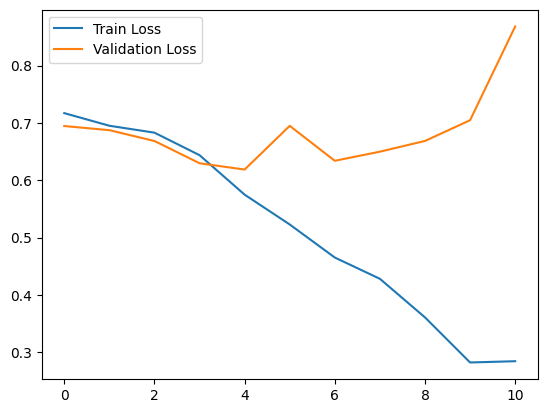

Accuracy: 0.7299999594688416


In [13]:
# Imports and installations
#!pip install transformers
#!pip install tqdm boto3 requests regex sentencepiece sacremoses

import copy
import math
import torch
import pandas as pd
import torch.optim as optim
import torch.nn as nn
from sklearn.model_selection import train_test_split
from collections import Counter
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# DEVICE SETUP (GPU SUPPORT)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
data = pd.read_csv("amazon_cells_labelled.txt", delimiter='\t')
data.columns = ['Sentence', 'Class']

# Preprocessing
def pre_data(data, max_len=50, test_size=0.2):

    def tokenize(text):
        return text.lower().split()

    vocab = Counter(word for s in data['Sentence'] for word in tokenize(s))
    vocab = {w: i + 1 for i, w in enumerate(vocab)}

    X = []
    for sentence in data['Sentence']:
        tokens = [vocab.get(w, 0) for w in tokenize(sentence)]
        tokens = tokens[:max_len] + [0] * (max_len - len(tokens))
        X.append(tokens)

    X = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(data['Class'].values, dtype=torch.long)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    return X_train, X_test, y_train, y_test, vocab


# Transformer
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, max_len=50):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 1, d_model)

        pe = torch.zeros(max_len, d_model)
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i] = math.sin(pos / (10000 ** (i / d_model)))
                if i + 1 < d_model:
                    pe[pos, i + 1] = math.cos(pos / (10000 ** (i / d_model)))

        self.register_buffer("pe", pe.unsqueeze(0))  # IMPORTANT: moves with model to GPU

        layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)

        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embedding(x)
        x = x + self.pe[:, :x.size(1)]
        x = self.transformer(x)
        return self.fc(x.mean(dim=1))


# Training
def train_model(model, trainloader, X_test, y_test, optimizer, criterion, epochs=100):

    train_losses, val_losses = [], []

    early_stop = 0
    best_acc = 0
    best_model = copy.deepcopy(model.state_dict())

    # move test data to GPU ONCE
    X_test = X_test.to(device)
    y_test = y_test.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(trainloader))

        # validation
        model.eval()
        with torch.no_grad():
            outputs = model(X_test)
            val_loss = criterion(outputs, y_test).item()
            val_losses.append(val_loss)

            preds = torch.argmax(outputs, dim=1)
            val_acc = (preds == y_test).float().mean().item()

        if val_acc > best_acc:
            best_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
        else:
            early_stop += 1

        if early_stop >= 3:
            break

        print(f"{epoch+1}: train={train_losses[-1]:.4f}, val={val_loss:.4f}, val_acc={val_acc:.4f}")

    model.load_state_dict(best_model)
    return train_losses, val_losses


# Evaluation
def evaluate(model, X_test, y_test, train_losses, val_losses):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        outputs = model(X_test)
        preds = torch.argmax(outputs, dim=1)

    accuracy = (preds == y_test).float().mean().item()
    print(f"Accuracy: {accuracy:.4f}")

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.legend()
    plt.show()

    return accuracy


# -----------------------------
# MAIN
# -----------------------------
X_train, X_test, y_train, y_test, vocab = pre_data(data)

trainloader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

model = TransformerModel(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_layers=2
).to(device)   # IMPORTANT

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = train_model(
    model,
    trainloader,
    X_test,
    y_test,
    optimizer,
    criterion,
)

accuracy = evaluate(model, X_test, y_test, train_losses, val_losses)
print("Accuracy:", accuracy)

In [11]:
"""
Task 1.3 – Model Comparison: Simple ANN vs Bi-LSTM vs Transformer
All three models trained on the same data split and compared on the same test set.
Run: python model_comparison.py
"""

# ─── Installs (uncomment if needed) ───────────────────────────────────────────
# pip install torch scikit-learn nltk pandas matplotlib seaborn

import math, copy, time, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # headless – swap to TkAgg / Qt5Agg if you want pop-ups
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
nltk.download("punkt",      quiet=True)
nltk.download("stopwords",  quiet=True)

from collections import Counter
from nltk.corpus import stopwords
from nltk import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

# ─── Config ───────────────────────────────────────────────────────────────────
DATA_PATH    = "amazon_cells_labelled.txt"
TEST_SIZE    = 0.15
RANDOM_STATE = 42
EPOCHS       = 15
BATCH_SIZE   = 32
LR           = 1e-3
MAX_LEN      = 60

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*60}")
print(f"  Device : {DEVICE}")
print(f"  Epochs : {EPOCHS}")
print(f"{'='*60}\n")


# ════════════════════════════════════════════════════════════════
# 1. PREPROCESSING
# ════════════════════════════════════════════════════════════════
def preprocess(data: pd.DataFrame) -> pd.DataFrame:
    stop = set(stopwords.words("english"))
    df   = data.copy()
    df["Sentence"] = df["Sentence"].str.lower()
    df["Sentence"] = df["Sentence"].replace(r"[a-zA-Z0-9_.]+@[a-zA-Z0-9_.]+", "", regex=True)
    df["Sentence"] = df["Sentence"].replace(r"(\d{1,3}\.){3}\d{1,3}", "",          regex=True)
    df["Sentence"] = df["Sentence"].str.replace(r"[^\w\s]", "",                     regex=True)
    df["Sentence"] = df["Sentence"].replace(r"\d+", "",                             regex=True)

    cleaned = []
    for sent in df["Sentence"]:
        tokens  = word_tokenize(sent)
        filtered = [w for w in tokens if w not in stop]
        cleaned.append(" ".join(filtered))
    df["Sentence"] = cleaned
    return df


def load_data(path: str):
    raw = pd.read_csv(path, delimiter="\t", header=None, names=["Sentence","Class"])
    raw = preprocess(raw)
    X_train, X_test, y_train, y_test = train_test_split(
        raw["Sentence"].values.astype("U"),
        raw["Class"].values.astype("int32"),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=raw["Class"].values
    )
    print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
    print(f"Class balance (train) – 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}\n")
    return X_train, X_test, y_train, y_test


# ════════════════════════════════════════════════════════════════
# 2. MODEL DEFINITIONS
# ════════════════════════════════════════════════════════════════
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128, dropout=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, 1)

    def forward(self, x, lengths):
        x      = self.emb(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(self.drop(h))


class TransformerCls(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_len=MAX_LEN):
        super().__init__()
        self.emb = nn.Embedding(vocab_size+1, d_model, padding_idx=0)

        pe = torch.zeros(max_len, d_model)
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i]   = math.sin(pos / (10000 ** (i / d_model)))
                if i+1 < d_model:
                    pe[pos, i+1] = math.cos(pos / (10000 ** (i / d_model)))
        self.register_buffer("pe", pe.unsqueeze(0))

        layer          = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=256,
                                                    batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.fc          = nn.Linear(d_model, 1)

    def forward(self, x, lengths=None):
        x = self.emb(x) + self.pe[:, :x.size(1)]
        x = self.transformer(x)
        return self.fc(x.mean(dim=1))


# ════════════════════════════════════════════════════════════════
# 3. DATA HELPERS
# ════════════════════════════════════════════════════════════════
def tfidf_loaders(X_train, X_test, y_train, y_test):
    vect = TfidfVectorizer(ngram_range=(1,2), max_features=30000)
    trX  = torch.tensor(vect.fit_transform(X_train).toarray(), dtype=torch.float32)
    teX  = torch.tensor(vect.transform(X_test).toarray(),      dtype=torch.float32)
    trY  = torch.tensor(y_train, dtype=torch.float32)
    teY  = torch.tensor(y_test,  dtype=torch.float32)
    tr   = DataLoader(TensorDataset(trX, trY), batch_size=BATCH_SIZE, shuffle=True)
    te   = DataLoader(TensorDataset(teX, teY), batch_size=BATCH_SIZE)
    return tr, te, trX.shape[1]


def build_vocab(sentences, max_size=8000):
    c = Counter(w for s in sentences for w in s.split())
    vocab = {w: i+2 for i,(w,_) in enumerate(c.most_common(max_size))}
    vocab["<PAD>"] = 0; vocab["<UNK>"] = 1
    return vocab


def encode_seq(sentences, vocab, max_len=MAX_LEN):
    seqs, lens = [], []
    for s in sentences:
        tok = s.split()
        seq = [vocab.get(w,1) for w in tok]
        lens.append(min(len(seq), max_len))
        seq = seq[:max_len] + [0]*(max_len - len(seq))
        seqs.append(seq)
    return np.array(seqs), np.array(lens)


def seq_loaders(X_train, X_test, y_train, y_test):
    vocab = build_vocab(X_train)
    trSeq, trLen = encode_seq(X_train, vocab)
    teSeq, teLen = encode_seq(X_test,  vocab)
    def make(seq, lbl, lng):
        return DataLoader(
            TensorDataset(torch.LongTensor(seq),
                          torch.FloatTensor(lbl),
                          torch.LongTensor(lng)),
            batch_size=BATCH_SIZE, shuffle=(lbl is y_train)
        )
    return make(trSeq, y_train, trLen), make(teSeq, y_test, teLen), len(vocab)


# ════════════════════════════════════════════════════════════════
# 4. TRAINING & EVALUATION
# ════════════════════════════════════════════════════════════════
def train_epoch(model, loader, criterion, optimizer):
    model.train(); total = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 3:
            X, y, lens = batch
            out = model(X.to(DEVICE), lens.to(DEVICE))
        else:
            X, y = batch
            out = model(X.to(DEVICE))
        y   = y.float().to(DEVICE).unsqueeze(1)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total += loss.item()
    return total / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval(); total = 0; preds_all = []; labels_all = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                X, y, lens = batch
                out = model(X.to(DEVICE), lens.to(DEVICE))
            else:
                X, y = batch
                out = model(X.to(DEVICE))
            y   = y.float().to(DEVICE).unsqueeze(1)
            total += criterion(out, y).item()
            preds_all.extend((torch.sigmoid(out) > 0.5).int().cpu().numpy())
            labels_all.extend(y.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    return total/len(loader), acc, preds_all, labels_all


def run_training(name, model, tr_loader, te_loader, criterion, optimizer):
    model = model.to(DEVICE)
    best_state = copy.deepcopy(model.state_dict()); best_val = float("inf")
    tr_losses=[]; val_losses=[]; val_accs=[]

    print(f"\n{'─'*50}")
    print(f"  Training: {name}")
    print(f"{'─'*50}")
    t0 = time.time()

    for ep in range(EPOCHS):
        tl = train_epoch(model, tr_loader, criterion, optimizer)
        vl, va, _, _ = eval_epoch(model, te_loader, criterion)
        tr_losses.append(tl); val_losses.append(vl); val_accs.append(va)
        print(f"  Epoch {ep+1:02d}/{EPOCHS} | train={tl:.4f}  val={vl:.4f}  acc={va:.4f}")
        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - t0
    model.load_state_dict(best_state)

    # final metrics
    _, _, preds, labels = eval_epoch(model, te_loader, criterion)
    metrics = {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
        "cm":        confusion_matrix(labels, preds),
        "report":    classification_report(labels, preds),
        "train_losses": tr_losses,
        "val_losses":   val_losses,
        "val_accs":     val_accs,
        "train_time_s": elapsed,
        "n_params":     sum(p.numel() for p in model.parameters() if p.requires_grad),
    }
    print(f"\n  Test accuracy : {metrics['accuracy']:.4f}")
    print(f"  F1-score      : {metrics['f1']:.4f}")
    print(f"  Train time    : {elapsed:.1f}s")
    print(f"  Parameters    : {metrics['n_params']:,}")
    print(metrics["report"])
    return model, metrics


# ════════════════════════════════════════════════════════════════
# 5. PLOTTING
# ════════════════════════════════════════════════════════════════
PALETTE = {"ANN": "#4C72B0", "Bi-LSTM": "#DD8452", "Transformer": "#55A868"}

def plot_all(results: dict):
    names = list(results.keys())
    fig   = plt.figure(figsize=(22, 20))
    fig.patch.set_facecolor("#F8F9FA")
    gs    = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── (A) Training loss curves ──────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["train_losses"], label=name,
                color=PALETTE[name], linewidth=2)
    ax.set_title("Training loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (B) Validation loss curves ───────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["val_losses"], label=name,
                color=PALETTE[name], linewidth=2, linestyle="--")
    ax.set_title("Validation loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (C) Validation accuracy curves ───────────────────────
    ax = fig.add_subplot(gs[0, 2])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["val_accs"], label=name,
                color=PALETTE[name], linewidth=2)
    ax.set_title("Validation accuracy", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 1.0); ax.legend()
    ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (D-F) Confusion matrices ──────────────────────────────
    for col, (name, m) in enumerate(results.items()):
        ax = fig.add_subplot(gs[1, col])
        sns.heatmap(m["cm"], annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
                    ax=ax, cbar=False, linewidths=0.5)
        ax.set_title(f"{name} – Confusion matrix", fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    # ── (G) Bar chart – metric comparison ────────────────────
    ax   = fig.add_subplot(gs[2, 0:2])
    metrics_labels = ["accuracy", "precision", "recall", "f1"]
    x    = np.arange(len(metrics_labels))
    w    = 0.25
    for i, (name, m) in enumerate(results.items()):
        vals = [m[k] for k in metrics_labels]
        bars = ax.bar(x + i*w, vals, width=w, label=name,
                      color=PALETTE[name], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels([m.capitalize() for m in metrics_labels])
    ax.set_ylim(0, 1.12); ax.set_title("Test metrics comparison", fontsize=13, fontweight="bold")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(axis="y", alpha=0.3)

    # ── (H) Parameters vs Accuracy bubble ────────────────────
    ax = fig.add_subplot(gs[2, 2])
    for name, m in results.items():
        ax.scatter(m["n_params"]/1e3, m["accuracy"]*100,
                   s=m["train_time_s"]*3+80,
                   color=PALETTE[name], alpha=0.85, edgecolors="white", linewidth=1.5, label=name)
        ax.annotate(name, (m["n_params"]/1e3, m["accuracy"]*100),
                    textcoords="offset points", xytext=(8,4), fontsize=9)
    ax.set_xlabel("Parameters (k)"); ax.set_ylabel("Test accuracy (%)")
    ax.set_title("Accuracy vs complexity\n(bubble size = train time)", fontsize=12, fontweight="bold")
    ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    fig.suptitle("Task 1.3 – Model comparison: ANN vs Bi-LSTM vs Transformer",
                 fontsize=16, fontweight="bold", y=0.98)

    out = "model_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"\n  Plot saved → {out}")
    return out


def print_summary_table(results: dict):
    print(f"\n{'='*70}")
    print(f"  FINAL COMPARISON TABLE")
    print(f"{'='*70}")
    header = f"{'Model':<14} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Params':>10} {'Time(s)':>9}"
    print(header)
    print("─"*70)
    for name, m in results.items():
        print(f"{name:<14} {m['accuracy']:>9.4f} {m['precision']:>10.4f} "
              f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
              f"{m['n_params']:>10,} {m['train_time_s']:>9.1f}")
    print("─"*70)


# ════════════════════════════════════════════════════════════════
# 6. MAIN
# ════════════════════════════════════════════════════════════════
def main():
    # ── Load data ──────────────────────────────────────────────
    X_train, X_test, y_train, y_test = load_data(DATA_PATH)
    results = {}

    # ── ANN (TF-IDF input) ─────────────────────────────────────
    tr_ann, te_ann, input_dim = tfidf_loaders(X_train, X_test, y_train, y_test)
    model_ann  = SimpleANN(input_dim)
    _, res_ann = run_training(
        "ANN", model_ann, tr_ann, te_ann,
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_ann.parameters(), lr=LR)
    )
    results["ANN"] = res_ann

    # ── Bi-LSTM ────────────────────────────────────────────────
    tr_lstm, te_lstm, vocab_size = seq_loaders(X_train, X_test, y_train, y_test)
    model_lstm  = BiLSTM(vocab_size)
    _, res_lstm = run_training(
        "Bi-LSTM", model_lstm, tr_lstm, te_lstm,
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_lstm.parameters(), lr=LR)
    )
    results["Bi-LSTM"] = res_lstm

    # ── Transformer ────────────────────────────────────────────
    model_tfm  = TransformerCls(vocab_size)
    _, res_tfm = run_training(
        "Transformer", model_tfm, tr_lstm, te_lstm,   # same seq loaders
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_tfm.parameters(), lr=5e-4)
    )
    results["Transformer"] = res_tfm

    # ── Report & plots ─────────────────────────────────────────
    print_summary_table(results)
    plot_all(results)

    print("\n  Done! Check 'model_comparison.png' for all charts.\n")


if __name__ == "__main__":
    main()


  Device : cuda
  Epochs : 15

Train: 850  |  Test: 150
Class balance (train) – 0: 425  1: 425


──────────────────────────────────────────────────
  Training: ANN
──────────────────────────────────────────────────
  Epoch 01/15 | train=0.6910  val=0.6834  acc=0.7667
  Epoch 02/15 | train=0.6168  val=0.5772  acc=0.7733
  Epoch 03/15 | train=0.2830  val=0.4637  acc=0.7800
  Epoch 04/15 | train=0.0442  val=0.5097  acc=0.8200
  Epoch 05/15 | train=0.0102  val=0.5607  acc=0.8000
  Epoch 06/15 | train=0.0057  val=0.5988  acc=0.8200
  Epoch 07/15 | train=0.0049  val=0.6226  acc=0.8200
  Epoch 08/15 | train=0.0031  val=0.6353  acc=0.8200
  Epoch 09/15 | train=0.0037  val=0.6422  acc=0.8067
  Epoch 10/15 | train=0.0041  val=0.6632  acc=0.8200
  Epoch 11/15 | train=0.0035  val=0.6707  acc=0.8067
  Epoch 12/15 | train=0.0048  val=0.7359  acc=0.8067
  Epoch 13/15 | train=0.0017  val=0.7006  acc=0.7933
  Epoch 14/15 | train=0.0024  val=0.6967  acc=0.8067
  Epoch 15/15 | train=0.0023  val=0.7105  

In [12]:
"""
Task 1.3 – Model Comparison: Simple ANN vs Bi-LSTM vs Transformer
Runs on BOTH the small (1k) and large (25k) datasets and saves a separate
PNG for each: model_comparison_SMALL.png and model_comparison_LARGE.png.
Run: python model_comparison.py
"""


# pip install torch scikit-learn nltk pandas matplotlib seaborn

import math, copy, time, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # headless – swap to TkAgg / Qt5Agg if you want pop-ups
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
nltk.download("punkt",      quiet=True)
nltk.download("stopwords",  quiet=True)

from collections import Counter
from nltk.corpus import stopwords
from nltk import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

# ─── Config ───────────────────────────────────────────────────────────────────
DATASETS = {
    "SMALL": "/home/jovyan/ludvig/lab1/amazon_cells_labelled.txt",
    "LARGE": "/home/jovyan/ludvig/lab1/amazon_cells_labelled_LARGE_25K.txt",
}
TEST_SIZE    = 0.15
RANDOM_STATE = 42
EPOCHS       = 15
BATCH_SIZE   = 32
LR           = 1e-3
MAX_LEN      = 60

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*60}")
print(f"  Device : {DEVICE}")
print(f"  Epochs : {EPOCHS}")
print(f"{'='*60}\n")


# ════════════════════════════════════════════════════════════════
# 1. PREPROCESSING
# ════════════════════════════════════════════════════════════════
def preprocess(data: pd.DataFrame) -> pd.DataFrame:
    stop = set(stopwords.words("english"))
    df   = data.copy()
    df["Sentence"] = df["Sentence"].str.lower()
    df["Sentence"] = df["Sentence"].replace(r"[a-zA-Z0-9_.]+@[a-zA-Z0-9_.]+", "", regex=True)
    df["Sentence"] = df["Sentence"].replace(r"(\d{1,3}\.){3}\d{1,3}", "",          regex=True)
    df["Sentence"] = df["Sentence"].str.replace(r"[^\w\s]", "",                     regex=True)
    df["Sentence"] = df["Sentence"].replace(r"\d+", "",                             regex=True)

    cleaned = []
    for sent in df["Sentence"]:
        tokens  = word_tokenize(sent)
        filtered = [w for w in tokens if w not in stop]
        cleaned.append(" ".join(filtered))
    df["Sentence"] = cleaned
    return df


def load_data(path: str):
    raw = pd.read_csv(path, delimiter="\t", header=None, names=["Sentence","Class"])
    raw = preprocess(raw)
    X_train, X_test, y_train, y_test = train_test_split(
        raw["Sentence"].values.astype("U"),
        raw["Class"].values.astype("int32"),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=raw["Class"].values
    )
    print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
    print(f"Class balance (train) – 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}\n")
    return X_train, X_test, y_train, y_test


# ════════════════════════════════════════════════════════════════
# 2. MODEL DEFINITIONS
# ════════════════════════════════════════════════════════════════
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128, dropout=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=2,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden*2, 1)

    def forward(self, x, lengths):
        x      = self.emb(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(self.drop(h))


class TransformerCls(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, max_len=MAX_LEN):
        super().__init__()
        self.emb = nn.Embedding(vocab_size+1, d_model, padding_idx=0)

        pe = torch.zeros(max_len, d_model)
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i]   = math.sin(pos / (10000 ** (i / d_model)))
                if i+1 < d_model:
                    pe[pos, i+1] = math.cos(pos / (10000 ** (i / d_model)))
        self.register_buffer("pe", pe.unsqueeze(0))

        layer          = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=256,
                                                    batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers)
        self.fc          = nn.Linear(d_model, 1)

    def forward(self, x, lengths=None):
        x = self.emb(x) + self.pe[:, :x.size(1)]
        x = self.transformer(x)
        return self.fc(x.mean(dim=1))


# ════════════════════════════════════════════════════════════════
# 3. DATA HELPERS
# ════════════════════════════════════════════════════════════════
def tfidf_loaders(X_train, X_test, y_train, y_test):
    vect = TfidfVectorizer(ngram_range=(1,2), max_features=30000)
    trX  = torch.tensor(vect.fit_transform(X_train).toarray(), dtype=torch.float32)
    teX  = torch.tensor(vect.transform(X_test).toarray(),      dtype=torch.float32)
    trY  = torch.tensor(y_train, dtype=torch.float32)
    teY  = torch.tensor(y_test,  dtype=torch.float32)
    tr   = DataLoader(TensorDataset(trX, trY), batch_size=BATCH_SIZE, shuffle=True)
    te   = DataLoader(TensorDataset(teX, teY), batch_size=BATCH_SIZE)
    return tr, te, trX.shape[1]


def build_vocab(sentences, max_size=8000):
    c = Counter(w for s in sentences for w in s.split())
    vocab = {w: i+2 for i,(w,_) in enumerate(c.most_common(max_size))}
    vocab["<PAD>"] = 0; vocab["<UNK>"] = 1
    return vocab


def encode_seq(sentences, vocab, max_len=MAX_LEN):
    seqs, lens = [], []
    for s in sentences:
        tok = s.split()
        seq = [vocab.get(w,1) for w in tok]
        lens.append(min(len(seq), max_len))
        seq = seq[:max_len] + [0]*(max_len - len(seq))
        seqs.append(seq)
    return np.array(seqs), np.array(lens)


def seq_loaders(X_train, X_test, y_train, y_test):
    vocab = build_vocab(X_train)
    trSeq, trLen = encode_seq(X_train, vocab)
    teSeq, teLen = encode_seq(X_test,  vocab)
    def make(seq, lbl, lng):
        return DataLoader(
            TensorDataset(torch.LongTensor(seq),
                          torch.FloatTensor(lbl),
                          torch.LongTensor(lng)),
            batch_size=BATCH_SIZE, shuffle=(lbl is y_train)
        )
    return make(trSeq, y_train, trLen), make(teSeq, y_test, teLen), len(vocab)


# ════════════════════════════════════════════════════════════════
# 4. TRAINING & EVALUATION
# ════════════════════════════════════════════════════════════════
def train_epoch(model, loader, criterion, optimizer):
    model.train(); total = 0
    for batch in loader:
        optimizer.zero_grad()
        if len(batch) == 3:
            X, y, lens = batch
            out = model(X.to(DEVICE), lens.to(DEVICE))
        else:
            X, y = batch
            out = model(X.to(DEVICE))
        y   = y.float().to(DEVICE).unsqueeze(1)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total += loss.item()
    return total / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval(); total = 0; preds_all = []; labels_all = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                X, y, lens = batch
                out = model(X.to(DEVICE), lens.to(DEVICE))
            else:
                X, y = batch
                out = model(X.to(DEVICE))
            y   = y.float().to(DEVICE).unsqueeze(1)
            total += criterion(out, y).item()
            preds_all.extend((torch.sigmoid(out) > 0.5).int().cpu().numpy())
            labels_all.extend(y.cpu().numpy())
    acc = accuracy_score(labels_all, preds_all)
    return total/len(loader), acc, preds_all, labels_all


def run_training(name, model, tr_loader, te_loader, criterion, optimizer):
    model = model.to(DEVICE)
    best_state = copy.deepcopy(model.state_dict()); best_val = float("inf")
    tr_losses=[]; val_losses=[]; val_accs=[]

    print(f"\n{'─'*50}")
    print(f"  Training: {name}")
    print(f"{'─'*50}")
    t0 = time.time()

    for ep in range(EPOCHS):
        tl = train_epoch(model, tr_loader, criterion, optimizer)
        vl, va, _, _ = eval_epoch(model, te_loader, criterion)
        tr_losses.append(tl); val_losses.append(vl); val_accs.append(va)
        print(f"  Epoch {ep+1:02d}/{EPOCHS} | train={tl:.4f}  val={vl:.4f}  acc={va:.4f}")
        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - t0
    model.load_state_dict(best_state)

    # final metrics
    _, _, preds, labels = eval_epoch(model, te_loader, criterion)
    metrics = {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
        "cm":        confusion_matrix(labels, preds),
        "report":    classification_report(labels, preds),
        "train_losses": tr_losses,
        "val_losses":   val_losses,
        "val_accs":     val_accs,
        "train_time_s": elapsed,
        "n_params":     sum(p.numel() for p in model.parameters() if p.requires_grad),
    }
    print(f"\n  Test accuracy : {metrics['accuracy']:.4f}")
    print(f"  F1-score      : {metrics['f1']:.4f}")
    print(f"  Train time    : {elapsed:.1f}s")
    print(f"  Parameters    : {metrics['n_params']:,}")
    print(metrics["report"])
    return model, metrics


# ════════════════════════════════════════════════════════════════
# 5. PLOTTING
# ════════════════════════════════════════════════════════════════
PALETTE = {"ANN": "#4C72B0", "Bi-LSTM": "#DD8452", "Transformer": "#55A868"}

def plot_all(results: dict, tag: str = ""):
    names = list(results.keys())
    fig   = plt.figure(figsize=(22, 20))
    fig.patch.set_facecolor("#F8F9FA")
    gs    = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── (A) Training loss curves ──────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["train_losses"], label=name,
                color=PALETTE[name], linewidth=2)
    ax.set_title("Training loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (B) Validation loss curves ───────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["val_losses"], label=name,
                color=PALETTE[name], linewidth=2, linestyle="--")
    ax.set_title("Validation loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (C) Validation accuracy curves ───────────────────────
    ax = fig.add_subplot(gs[0, 2])
    for name, m in results.items():
        ax.plot(range(1, EPOCHS+1), m["val_accs"], label=name,
                color=PALETTE[name], linewidth=2)
    ax.set_title("Validation accuracy", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 1.0); ax.legend()
    ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    # ── (D-F) Confusion matrices ──────────────────────────────
    for col, (name, m) in enumerate(results.items()):
        ax = fig.add_subplot(gs[1, col])
        sns.heatmap(m["cm"], annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
                    ax=ax, cbar=False, linewidths=0.5)
        ax.set_title(f"{name} – Confusion matrix", fontsize=12, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    # ── (G) Bar chart – metric comparison ────────────────────
    ax   = fig.add_subplot(gs[2, 0:2])
    metrics_labels = ["accuracy", "precision", "recall", "f1"]
    x    = np.arange(len(metrics_labels))
    w    = 0.25
    for i, (name, m) in enumerate(results.items()):
        vals = [m[k] for k in metrics_labels]
        bars = ax.bar(x + i*w, vals, width=w, label=name,
                      color=PALETTE[name], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels([m.capitalize() for m in metrics_labels])
    ax.set_ylim(0, 1.12); ax.set_title("Test metrics comparison", fontsize=13, fontweight="bold")
    ax.legend(); ax.set_facecolor("#FFFFFF"); ax.grid(axis="y", alpha=0.3)

    # ── (H) Parameters vs Accuracy bubble ────────────────────
    ax = fig.add_subplot(gs[2, 2])
    for name, m in results.items():
        ax.scatter(m["n_params"]/1e3, m["accuracy"]*100,
                   s=m["train_time_s"]*3+80,
                   color=PALETTE[name], alpha=0.85, edgecolors="white", linewidth=1.5, label=name)
        ax.annotate(name, (m["n_params"]/1e3, m["accuracy"]*100),
                    textcoords="offset points", xytext=(8,4), fontsize=9)
    ax.set_xlabel("Parameters (k)"); ax.set_ylabel("Test accuracy (%)")
    ax.set_title("Accuracy vs complexity\n(bubble size = train time)", fontsize=12, fontweight="bold")
    ax.set_facecolor("#FFFFFF"); ax.grid(alpha=0.3)

    fig.suptitle(f"Task 1.3 – Model comparison: ANN vs Bi-LSTM vs Transformer  [{tag} dataset]",
                 fontsize=16, fontweight="bold", y=0.98)

    out = f"model_comparison_{tag}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"\n  Plot saved → {out}")
    return out


def print_summary_table(results: dict):
    print(f"\n{'='*70}")
    print(f"  FINAL COMPARISON TABLE")
    print(f"{'='*70}")
    header = f"{'Model':<14} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Params':>10} {'Time(s)':>9}"
    print(header)
    print("─"*70)
    for name, m in results.items():
        print(f"{name:<14} {m['accuracy']:>9.4f} {m['precision']:>10.4f} "
              f"{m['recall']:>8.4f} {m['f1']:>8.4f} "
              f"{m['n_params']:>10,} {m['train_time_s']:>9.1f}")
    print("─"*70)


# ════════════════════════════════════════════════════════════════
# 6. MAIN
# ════════════════════════════════════════════════════════════════
def run_experiment(tag: str, data_path: str):
    print(f"\n{'#'*60}")
    print(f"  EXPERIMENT: {tag} dataset")
    print(f"  Path: {data_path}")
    print(f"{'#'*60}")

    X_train, X_test, y_train, y_test = load_data(data_path)
    results = {}

    # ── ANN (TF-IDF input) ─────────────────────────────────────
    tr_ann, te_ann, input_dim = tfidf_loaders(X_train, X_test, y_train, y_test)
    model_ann  = SimpleANN(input_dim)
    _, res_ann = run_training(
        "ANN", model_ann, tr_ann, te_ann,
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_ann.parameters(), lr=LR)
    )
    results["ANN"] = res_ann
    
    # ── Bi-LSTM ────────────────────────────────────────────────
    tr_lstm, te_lstm, vocab_size = seq_loaders(X_train, X_test, y_train, y_test)
    model_lstm  = BiLSTM(vocab_size)
    _, res_lstm = run_training(
        "Bi-LSTM", model_lstm, tr_lstm, te_lstm,
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_lstm.parameters(), lr=LR)
    )
    results["Bi-LSTM"] = res_lstm

    # ── Transformer ────────────────────────────────────────────
    model_tfm  = TransformerCls(vocab_size)
    _, res_tfm = run_training(
        "Transformer", model_tfm, tr_lstm, te_lstm,   # same seq loaders
        nn.BCEWithLogitsLoss(),
        optim.Adam(model_tfm.parameters(), lr=5e-4)
    )
    results["Transformer"] = res_tfm

    # ── Report & plots ─────────────────────────────────────────
    print_summary_table(results)
    plot_all(results, tag=tag)
    return results


def main():
    all_results = {}
    for tag, path in DATASETS.items():
        all_results[tag] = run_experiment(tag, path)

    # ── Cross-dataset accuracy summary ─────────────────────────
    print(f"\n{'='*70}")
    print(f"  CROSS-DATASET ACCURACY SUMMARY")
    print(f"{'='*70}")
    print(f"{'Model':<14} {'SMALL acc':>12} {'LARGE acc':>12} {'Delta':>10}")
    print("─"*70)
    for model in ["ANN", "Bi-LSTM", "Transformer"]:
        s = all_results["SMALL"][model]["accuracy"]
        l = all_results["LARGE"][model]["accuracy"]
        print(f"{model:<14} {s:>12.4f} {l:>12.4f} {l-s:>+10.4f}")
    print("─"*70)

    print("\n  Done! Saved model_comparison_SMALL.png and model_comparison_LARGE.png\n")


if __name__ == "__main__":
    main()


  Device : cuda
  Epochs : 15


############################################################
  EXPERIMENT: SMALL dataset
  Path: /home/jovyan/ludvig/lab1/amazon_cells_labelled.txt
############################################################
Train: 850  |  Test: 150
Class balance (train) – 0: 425  1: 425


──────────────────────────────────────────────────
  Training: ANN
──────────────────────────────────────────────────
  Epoch 01/15 | train=0.6923  val=0.6859  acc=0.6533
  Epoch 02/15 | train=0.6343  val=0.6008  acc=0.7667
  Epoch 03/15 | train=0.3342  val=0.4407  acc=0.7933
  Epoch 04/15 | train=0.0600  val=0.5074  acc=0.8067
  Epoch 05/15 | train=0.0126  val=0.5712  acc=0.8067
  Epoch 06/15 | train=0.0104  val=0.6114  acc=0.8000
  Epoch 07/15 | train=0.0075  val=0.6579  acc=0.8133
  Epoch 08/15 | train=0.0047  val=0.6573  acc=0.7933
  Epoch 09/15 | train=0.0028  val=0.6974  acc=0.8200
  Epoch 10/15 | train=0.0035  val=0.6892  acc=0.7933
  Epoch 11/15 | train=0.0025  val=0.7017  ac

In [13]:
!nvidia-smi

Tue Apr 14 14:29:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:23:00.0 Off |                  N/A |
| 31%   26C    P8             11W /  250W |    1696MiB /  11264MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----